# Frequency-Velocity CNN for Near-Surface 2D Vs Inversion

**Implementation of:** "A frequency-velocity CNN for developing near-surface 2D vs images" (2023)


**Exercise:** [![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=flat-square&logo=googlecolab)](https://colab.research.google.com/github/kks32-courses/ai-geotech/blob/main/docs/03-cnn/cnn-fwi-velocity-exercise.ipynb)
**Solution:** [![Open in Colab](https://img.shields.io/badge/Open%20in-Colab-F9AB00?style=flat-square&logo=googlecolab)](https://colab.research.google.com/github/kks32-courses/ai-geotech/blob/main/docs/03-cnn/cnn-fwi-velocity.ipynb)

**Learning Objectives:**
- Understand CNN architecture for geophysical inversion
- Learn Full Waveform Inversion (FWI) using deep learning
- Implement GradCAM for model interpretation
- Master PyTorch for seismic data processing

**Dataset:**
- **Input**: Frequency-velocity transforms (400 x 76) - dispersion curves
- **Output**: 2D Vs velocity models (24 x 48) - shear wave velocity
- **Training**: 10 files × 500 samples = 5,000 samples
- **Testing**: 2 files × 500 samples = 1,000 samples

**References:**
1. 2023 Elsevier - A frequency-velocity CNN for developing near-surface 2D vs images.pdf
2. Jodie Crocker (2023) - Machine learning interpretation with GradCAM

## 1. Import Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn.functional as F

import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
import os

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from skimage.metrics import structural_similarity as ssim

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# Set device - MPS (Apple Silicon) > CUDA > CPU
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print("🚀 Using Apple Silicon GPU (MPS)")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print("🚀 Using NVIDIA GPU (CUDA)")
else:
    device = torch.device('cpu')
    print("⚠️  Using CPU")

print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

🚀 Using NVIDIA GPU (CUDA)
Device: cuda
PyTorch version: 2.8.0+cu126


## 2. Load HDF5 Dataset

We'll use 4 training files and 2 testing files for faster experimentation.

In [2]:
from huggingface_hub import snapshot_download

# Download the entire dataset repository
local_dir = snapshot_download(
    repo_id="kks32/cnn-dataset",
    repo_type="dataset",
    local_dir="./"
)

print(f"Dataset downloaded to: {local_dir}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

.gitattributes: 0.00B [00:00, ?B/s]

training_dataset-selected/new_sor_500sim(…):   0%|          | 0.00/142M [00:00<?, ?B/s]

training_dataset-selected/new_sor_500sim(…):   0%|          | 0.00/142M [00:00<?, ?B/s]

...

training_dataset-selected/new_sor_500sim(…):   0%|          | 0.00/142M [00:00<?, ?B/s]

training_dataset-selected/new_sor_500sim(…):   0%|          | 0.00/142M [00:00<?, ?B/s]

training_dataset-selected/new_sor_500sim(…):   0%|          | 0.00/142M [00:00<?, ?B/s]

training_dataset-selected/new_sor_500sim(…):   0%|          | 0.00/142M [00:00<?, ?B/s]

Dataset downloaded to: /content


In [3]:
def load_hdf5_data(file_paths, key_input='transforms', key_output='models'):
    """
    Load data from multiple HDF5 files.

    Args:
        file_paths: List of HDF5 file paths
        key_input: Key for input data (transforms)
        key_output: Key for output data (models)

    Returns:
        inputs, outputs as numpy arrays
    """
    inputs_list = []
    outputs_list = []

    print(f"📂 Loading {len(file_paths)} HDF5 files...")
    for file_path in tqdm(file_paths):
        with h5py.File(file_path, 'r') as f:
            # Load transforms (input) - shape: (500, 400, 76)
            transforms = f[key_input][:]
            # Add channel dimension: (500, 400, 76) -> (500, 1, 400, 76)
            transforms = transforms.reshape(transforms.shape[0], 1, 400, 76)

            # Load models (output) - shape: (500, 24, 48, 1)
            models = f[key_output][:]
            # Reshape: (500, 24, 48, 1) -> (500, 24, 48)
            models = models.reshape(models.shape[0], 24, 48)

            inputs_list.append(transforms)
            outputs_list.append(models)

    inputs = np.concatenate(inputs_list, axis=0).astype(np.float32)
    outputs = np.concatenate(outputs_list, axis=0).astype(np.float32)

    print(f"✅ Loaded data:")
    print(f"   Inputs (transforms): {inputs.shape}")
    print(f"   Outputs (models): {outputs.shape}")

    return inputs, outputs


# Define file paths
train_dir = Path('training_dataset-selected')
test_dir = Path('testing_dataset-selected')

# Use subset: 10 training files, 2 testing files
train_files = [
    train_dir / 'new_sor_500sim_b149.hdf5',
    train_dir / 'new_sor_500sim_b150.hdf5',
    train_dir / 'new_sor_500sim_b152.hdf5',
    train_dir / 'new_sor_500sim_b153.hdf5',
    train_dir / 'new_sor_500sim_b154.hdf5',
    train_dir / 'new_sor_500sim_b155.hdf5',
    train_dir / 'new_sor_500sim_b156.hdf5',
    train_dir / 'new_sor_500sim_b157.hdf5',
    train_dir / 'new_sor_500sim_b158.hdf5',
    train_dir / 'new_sor_500sim_b159.hdf5',
]

test_files = [
    test_dir / 'new_sor_500sim_b19.hdf5',
    test_dir / 'new_sor_500sim_b23.hdf5',
]

# Load training data
print("\n🔄 Loading training data...")
train_inputs, train_outputs = load_hdf5_data(train_files)

# Load testing data
print("\n🔄 Loading testing data...")
test_inputs, test_outputs = load_hdf5_data(test_files)

print(f"\n📊 Dataset Summary:")
print(f"   Training: {len(train_inputs)} samples")
print(f"   Testing: {len(test_inputs)} samples")


🔄 Loading training data...
📂 Loading 10 HDF5 files...


  0%|          | 0/10 [00:00<?, ?it/s]

✅ Loaded data:
   Inputs (transforms): (5000, 1, 400, 76)
   Outputs (models): (5000, 24, 48)

🔄 Loading testing data...
📂 Loading 2 HDF5 files...


  0%|          | 0/2 [00:00<?, ?it/s]

✅ Loaded data:
   Inputs (transforms): (1000, 1, 400, 76)
   Outputs (models): (1000, 24, 48)

📊 Dataset Summary:
   Training: 5000 samples
   Testing: 1000 samples


## 3. Visualize Sample Data

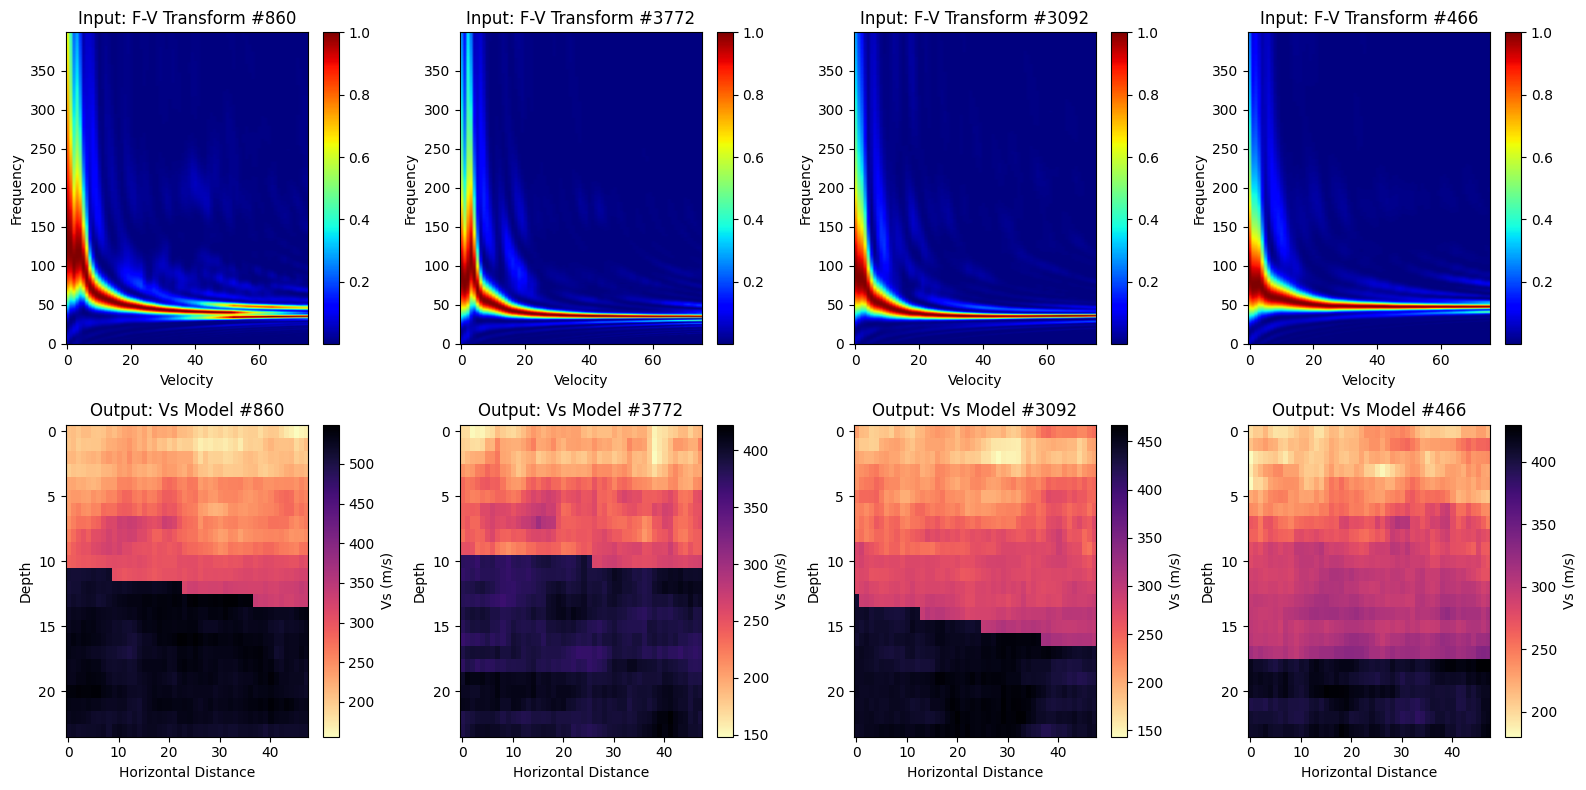

In [4]:
# Plot random samples
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    idx = np.random.randint(0, len(train_inputs))

    # Plot input (frequency-velocity transform)
    ax = axes[0, i]
    im = ax.imshow(train_inputs[idx, 0], aspect='auto', cmap='jet', origin='lower')
    ax.set_title(f'Input: F-V Transform #{idx}')
    ax.set_xlabel('Velocity')
    ax.set_ylabel('Frequency')
    plt.colorbar(im, ax=ax)

    # Plot output (velocity model)
    ax = axes[1, i]
    im = ax.imshow(train_outputs[idx], aspect='auto', cmap='magma_r', origin='upper')
    ax.set_title(f'Output: Vs Model #{idx}')
    ax.set_xlabel('Horizontal Distance')
    ax.set_ylabel('Depth')
    plt.colorbar(im, ax=ax, label='Vs (m/s)')

plt.tight_layout()
plt.show()

## 4. Create PyTorch Datasets

In [5]:
# Convert to PyTorch tensors
train_inputs_tensor = torch.FloatTensor(train_inputs)
train_outputs_tensor = torch.FloatTensor(train_outputs)
test_inputs_tensor = torch.FloatTensor(test_inputs)
test_outputs_tensor = torch.FloatTensor(test_outputs)

# Create datasets
train_dataset = TensorDataset(train_inputs_tensor, train_outputs_tensor)
test_dataset = TensorDataset(test_inputs_tensor, test_outputs_tensor)

# OPTIMIZED FOR COLAB/CUDA
# Increase batch size for better GPU utilization
batch_size = 64  # Increase from 32 to 64 (or try 128)

# Create dataloaders with CUDA optimizations
if torch.cuda.is_available():
    # CUDA optimizations
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,      # Use multiple workers for data loading
        pin_memory=True     # Speed up CPU→GPU transfer
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )
    print("🚀 Using CUDA optimizations:")
    print("   - pin_memory=True (faster CPU→GPU transfer)")
    print("   - num_workers=2 (parallel data loading)")
    print(f"   - batch_size={batch_size} (increased for GPU)")
else:
    # MPS/CPU - use defaults
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    print("⚠️  Using default dataloader (MPS/CPU)")

print(f"\n✅ DataLoaders created:")
print(f"   Batch size: {batch_size}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Test batches: {len(test_loader)}")

🚀 Using CUDA optimizations:
   - pin_memory=True (faster CPU→GPU transfer)
   - num_workers=2 (parallel data loading)
   - batch_size=64 (increased for GPU)

✅ DataLoaders created:
   Batch size: 64
   Train batches: 79
   Test batches: 16


## 5. CNN Architecture for FWI

**Architecture based on the paper:**
```
Input: (1, 400, 76) - Frequency-Velocity Transform
    ↓
Conv2D(32, 5x5) + ReLU + MaxPool(2x2)
    ↓
Conv2D(64, 5x5) + ReLU + MaxPool(2x2)
    ↓
Conv2D(128, 3x3) + ReLU + MaxPool(2x2)
    ↓
Conv2D(256, 3x3) + ReLU + MaxPool(2x2)
    ↓
Flatten + Dropout(0.5)
    ↓
Dense(2048) + ReLU + Dropout(0.3)
    ↓
Dense(1024) + ReLU
    ↓
Dense(24×48=1152) + Reshape
    ↓
Output: (24, 48) - 2D Vs Model
```

In [6]:
class FrequencyVelocityCNN(nn.Module):
    def __init__(self):
        super(FrequencyVelocityCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )  # Output: (32, 200, 38)

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )  # Output: (64, 100, 19)

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )  # Output: (128, 50, 9)

        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )  # Output: (256, 25, 4)

        # Calculate flattened size
        self.flatten_size = 256 * 25 * 4

        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(self.flatten_size, 2048),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Linear(1024, 24 * 48)  # Output size: 1152
        )

    def forward(self, x):
        # Convolutional layers
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        # Fully connected layers
        x = self.fc(x)

        # Reshape to 2D velocity model
        x = x.view(-1, 24, 48)

        return x


# Create model
model = FrequencyVelocityCNN()
model = model.to(device)

print(model)
print(f"\n📊 Model Parameters:")
print(f"   Total: {sum(p.numel() for p in model.parameters()):,}")
print(f"   Trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

FrequencyVelocityCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=25600, out_features=2048, bias=True)
  

## 6. Training Configuration

In [ ]:
# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

## 7. Training Function

In [8]:
def train_model(model, train_loader, test_loader, criterion, optimizer, scheduler,
                num_epochs=50, device='cpu', save_path='best_fwi_cnn.pth'):
    """
    Train the FWI CNN model.
    """
    history = {
        'train_loss': [],
        'test_loss': [],
        'test_mae': [],
    }

    best_test_loss = float('inf')

    print(f"🏃 Training on {device}...\n")

    for epoch in tqdm(range(num_epochs), desc='Epochs'):
        # Training
        model.train()
        train_loss = 0.0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # Testing
        model.eval()
        test_loss = 0.0
        test_mae = 0.0

        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)

                loss = criterion(outputs, targets)
                mae = F.l1_loss(outputs, targets)

                test_loss += loss.item()
                test_mae += mae.item()

        test_loss /= len(test_loader)
        test_mae /= len(test_loader)

        # Update history
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['test_mae'].append(test_mae)

        # Update learning rate
        scheduler.step(test_loss)

        # Save best model
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            torch.save(model.state_dict(), save_path)

        # Print progress
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{num_epochs} | '
                  f'Train Loss: {train_loss:.4f} | '
                  f'Test Loss: {test_loss:.4f} | '
                  f'Test MAE: {test_mae:.2f}')

    print(f'\n✅ Training completed! Best test loss: {best_test_loss:.4f}')

    # Load best model
    model.load_state_dict(torch.load(save_path))

    return history

## 8. Train the Model

In [9]:
# Train
history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=150,
    device=device,
    save_path='best_fwi_cnn.pth'
)

🏃 Training on cuda...



Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 10/150 | Train Loss: 5507.5541 | Test Loss: 5456.4159 | Test MAE: 52.03
Epoch 20/150 | Train Loss: 2853.5415 | Test Loss: 2791.7491 | Test MAE: 31.28
Epoch 30/150 | Train Loss: 2405.9161 | Test Loss: 2593.3951 | Test MAE: 28.67
Epoch 40/150 | Train Loss: 2127.6948 | Test Loss: 2626.6898 | Test MAE: 28.59
Epoch 50/150 | Train Loss: 1981.1365 | Test Loss: 2583.5664 | Test MAE: 27.69
Epoch 60/150 | Train Loss: 1945.5482 | Test Loss: 2589.1016 | Test MAE: 27.56
Epoch 70/150 | Train Loss: 1899.2169 | Test Loss: 2582.2528 | Test MAE: 27.28
Epoch 80/150 | Train Loss: 1916.0730 | Test Loss: 2593.3106 | Test MAE: 27.50
Epoch 90/150 | Train Loss: 1904.2785 | Test Loss: 2597.1365 | Test MAE: 27.50
Epoch 100/150 | Train Loss: 1902.6225 | Test Loss: 2596.2972 | Test MAE: 27.48
Epoch 110/150 | Train Loss: 1897.3471 | Test Loss: 2596.2824 | Test MAE: 27.47
Epoch 120/150 | Train Loss: 1894.9968 | Test Loss: 2596.0931 | Test MAE: 27.47
Epoch 130/150 | Train Loss: 1901.0028 | Test Loss: 2596.1097 

## 9. Visualize Training History

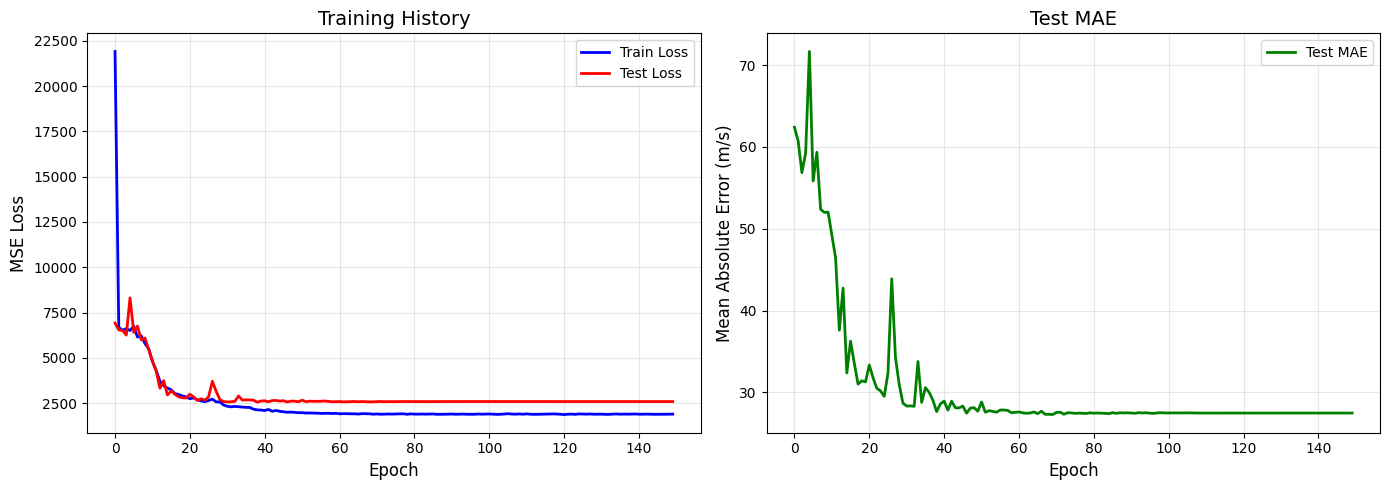

Final train loss: 1905.0587
Final test loss: 2595.7858
Final test MAE: 27.47 m/s


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
axes[0].plot(history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0].plot(history['test_loss'], 'r-', label='Test Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Training History', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot MAE
axes[1].plot(history['test_mae'], 'g-', label='Test MAE', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Mean Absolute Error (m/s)', fontsize=12)
axes[1].set_title('Test MAE', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final train loss: {history['train_loss'][-1]:.4f}")
print(f"Final test loss: {history['test_loss'][-1]:.4f}")
print(f"Final test MAE: {history['test_mae'][-1]:.2f} m/s")

#### Load model

In [21]:
# # To load the model later:
# model_loaded = FrequencyVelocityCNN()
# model_loaded.load_state_dict(torch.load('best_fwi_cnn.pth'))
# model_loaded = model_loaded.to(device)
# model_loaded.eval()

FrequencyVelocityCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=25600, out_features=2048, bias=True)
  

## 10. Evaluate Model Performance

In [22]:
# Make predictions on test set
model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)

        all_predictions.append(outputs.cpu().numpy())
        all_targets.append(targets.numpy())

predictions = np.concatenate(all_predictions, axis=0)
targets = np.concatenate(all_targets, axis=0)

# Calculate metrics
mse = mean_squared_error(targets.flatten(), predictions.flatten())
mae = mean_absolute_error(targets.flatten(), predictions.flatten())
r2 = r2_score(targets.flatten(), predictions.flatten())

# Calculate SSIM for each sample
ssim_scores = []
for i in range(len(predictions)):
    score = ssim(targets[i], predictions[i], data_range=targets[i].max() - targets[i].min())
    ssim_scores.append(score)

mean_ssim = np.mean(ssim_scores)

print("📊 Test Set Performance:")
print(f"   MSE: {mse:.4f}")
print(f"   MAE: {mae:.2f} m/s")
print(f"   R²: {r2:.4f}")
print(f"   Mean SSIM: {mean_ssim:.4f}")

# Also evaluate on TRAINING set to check for overfitting/underfitting
print("\n🔍 Evaluating on Training Set (to diagnose overfitting/underfitting)...")
train_predictions = []
train_targets_list = []

with torch.no_grad():
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)

        train_predictions.append(outputs.cpu().numpy())
        train_targets_list.append(targets.numpy())

train_preds = np.concatenate(train_predictions, axis=0)
train_targs = np.concatenate(train_targets_list, axis=0)

# Calculate training metrics
train_mse = mean_squared_error(train_targs.flatten(), train_preds.flatten())
train_mae = mean_absolute_error(train_targs.flatten(), train_preds.flatten())
train_r2 = r2_score(train_targs.flatten(), train_preds.flatten())

# Calculate SSIM for training
train_ssim_scores = []
for i in range(min(100, len(train_preds))):  # Sample 100 for speed
    score = ssim(train_targs[i], train_preds[i], data_range=train_targs[i].max() - train_targs[i].min())
    train_ssim_scores.append(score)
train_mean_ssim = np.mean(train_ssim_scores)

print("\n📊 Training Set Performance:")
print(f"   MSE: {train_mse:.4f}")
print(f"   MAE: {train_mae:.2f} m/s")
print(f"   R²: {train_r2:.4f}")
print(f"   Mean SSIM (sampled): {train_mean_ssim:.4f}")

print("\n" + "="*60)
print("🔬 DIAGNOSIS:")
print("="*60)

# Overfitting check
if train_mse < mse * 0.5:
    print("⚠️  OVERFITTING DETECTED!")
    print("   Training loss much better than test loss")
    print("   → Recommendation:")
    print("     1. Add more dropout (increase from 0.5 to 0.6)")
    print("     2. Use data augmentation")
    print("     3. Reduce model complexity")
    print("     4. Add L2 regularization")
    print("     5. Use more training data")
elif abs(train_mse - mse) < mse * 0.2:
    print("✅ GOOD GENERALIZATION")
    print("   Training and test performance similar")
    print("   → To improve further:")
    print("     1. Increase model capacity (more layers/filters)")
    print("     2. Train longer (more epochs)")
    print("     3. Use more training data (all 10 files)")
    print("     4. Try different architecture")
else:
    print("⚠️  UNDERFITTING SUSPECTED")
    print("   Both train and test loss are high")
    print("   → Recommendation:")
    print("     1. Increase model capacity (deeper/wider)")
    print("     2. Train longer (100-200 epochs)")
    print("     3. Lower learning rate")
    print("     4. Use batch normalization")
    print("     5. Use ALL training data (10 files)")

# Performance assessment
if r2 > 0.95:
    print("\n🌟 EXCELLENT performance (R² > 0.95)")
elif r2 > 0.85:
    print("\n✅ GOOD performance (R² > 0.85)")
elif r2 > 0.70:
    print("\n⚠️  MODERATE performance (R² > 0.70)")
    print("   Model needs improvement!")
else:
    print("\n❌ POOR performance (R² < 0.70)")
    print("   Significant improvement needed!")

print("\n" + "="*60)
print("💡 KEY RECOMMENDATIONS:")
print("="*60)

if r2 < 0.85:
    print("\n1️⃣  USE MORE DATA")
    print(f"   Current: {len(train_inputs)} samples (4 files)")
    print("   Recommended: Use all 10 training files (5,000 samples)")
    print("   → This will likely give biggest improvement!")

    print("\n2️⃣  TRAIN LONGER")
    print("   Current: 50 epochs")
    print("   Recommended: 100-200 epochs with early stopping")

    print("\n3️⃣  CHECK DATA NORMALIZATION")
    print(f"   Input range: [{train_inputs.min():.2f}, {train_inputs.max():.2f}]")
    print(f"   Output range: [{train_outputs.min():.2f}, {train_outputs.max():.2f}]")
    if train_outputs.max() > 10:
        print("   ⚠️  Output not normalized! Consider normalizing to [0, 1]")

    print("\n4️⃣  TRY LEARNING RATE SCHEDULE")
    print("   Start with lr=0.001, reduce on plateau")
    print("   Or use cosine annealing")

print("\n" + "="*60)

📊 Test Set Performance:
   MSE: 2567.1687
   MAE: 27.68 m/s
   R²: 0.9208
   Mean SSIM: 0.6794

🔍 Evaluating on Training Set (to diagnose overfitting/underfitting)...

📊 Training Set Performance:
   MSE: 1875.4224
   MAE: 24.65 m/s
   R²: 0.9411
   Mean SSIM (sampled): 0.6874

🔬 DIAGNOSIS:
⚠️  UNDERFITTING SUSPECTED
   Both train and test loss are high
   → Recommendation:
     1. Increase model capacity (deeper/wider)
     2. Train longer (100-200 epochs)
     3. Lower learning rate
     4. Use batch normalization
     5. Use ALL training data (10 files)

✅ GOOD performance (R² > 0.85)

💡 KEY RECOMMENDATIONS:



## 10b. Visual Comparison: Training vs Test Performance

Let's visualize predictions on both training and test data side-by-side.

Train predictions shape: (5000, 24, 48)
Test predictions shape: (1000, 24, 48)
Train targets shape: (5000, 24, 48)
Test targets shape: (8, 24, 48)


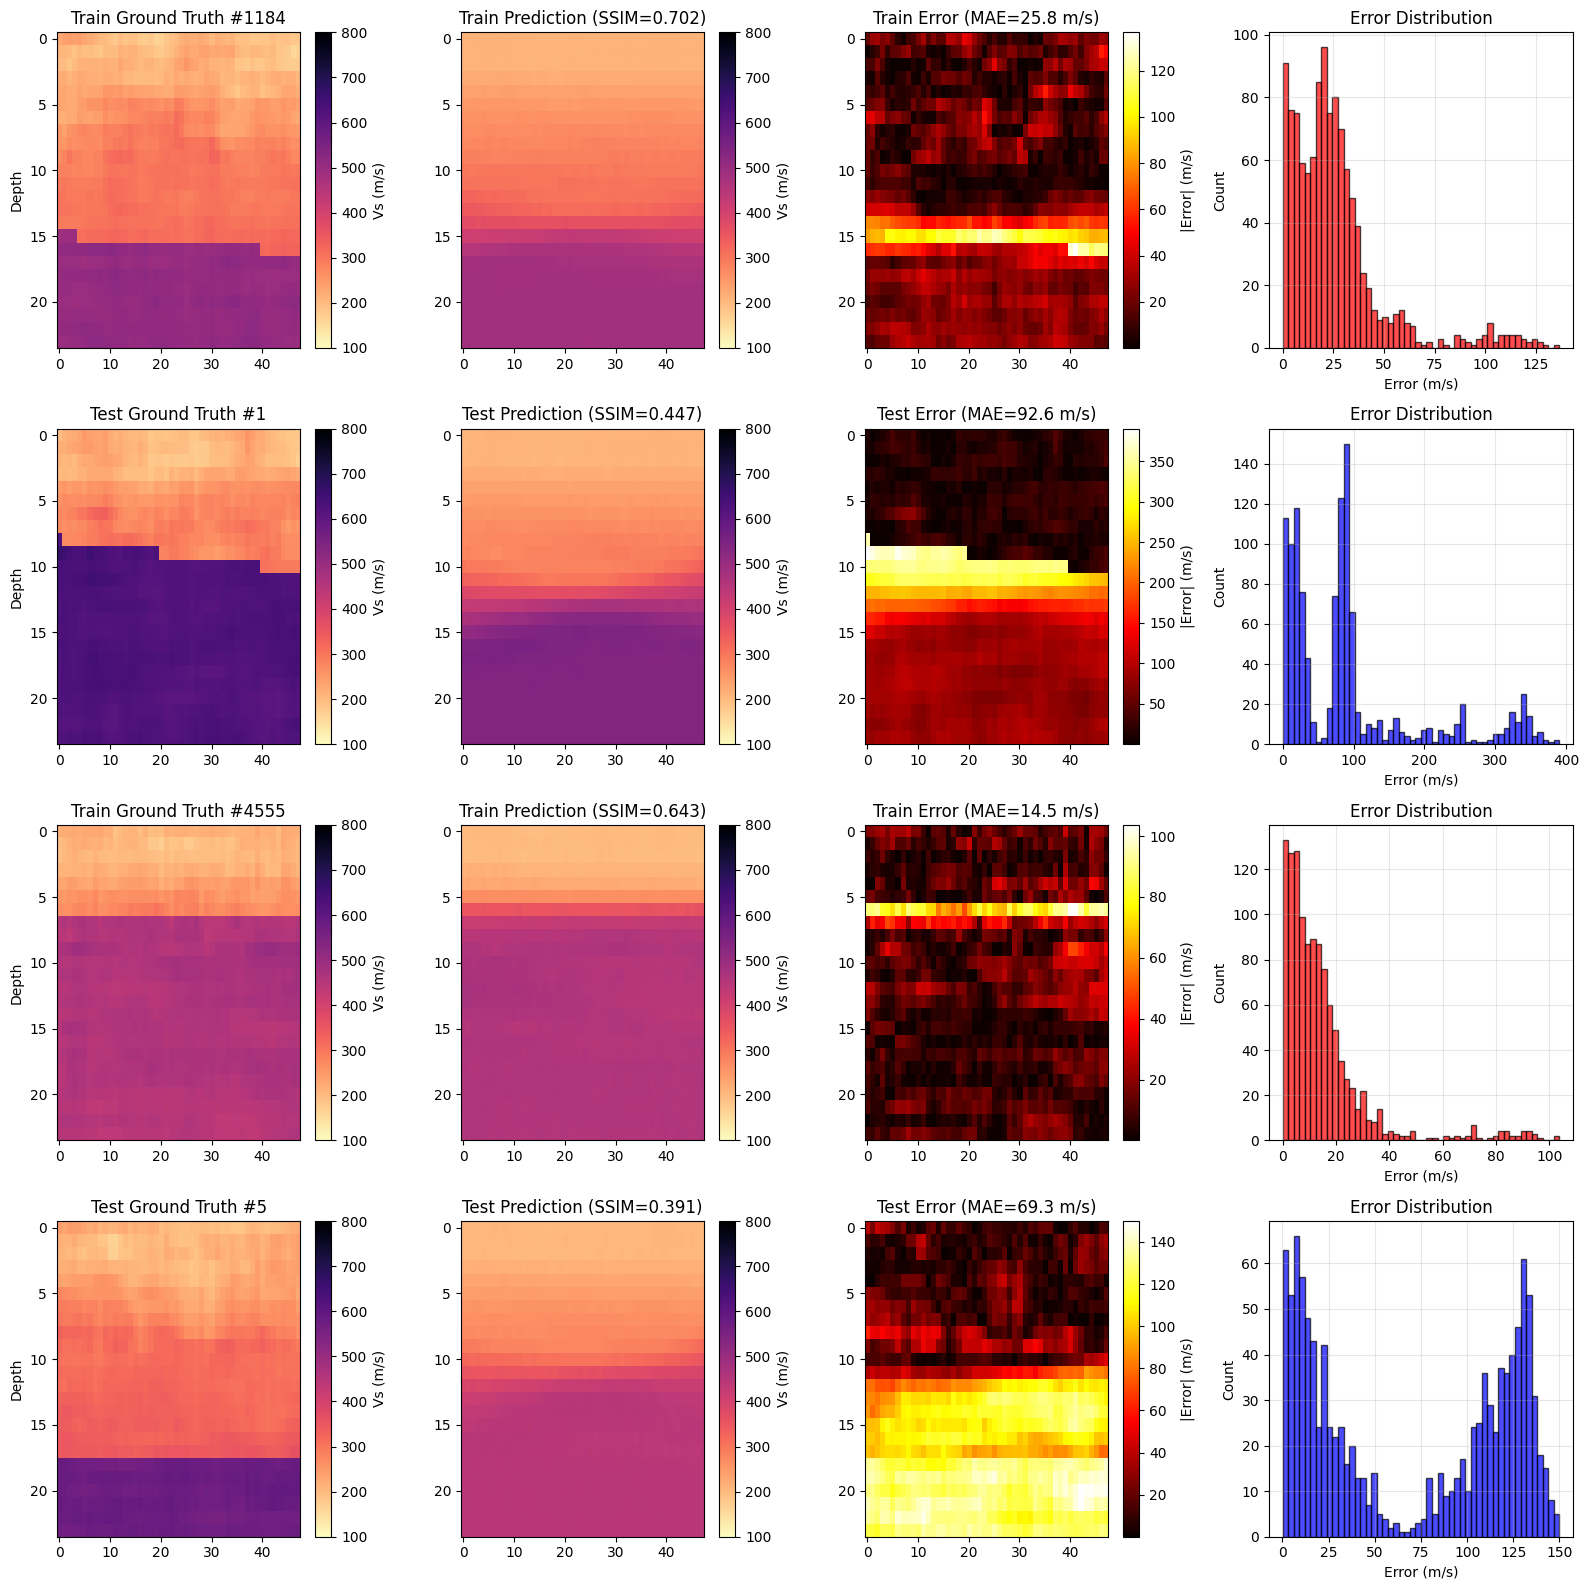


📊 Comparison Summary:
   Training MAE: 24.65 m/s
   Test MAE: 27.68 m/s
   Difference: 3.03 m/s
   ✅ Good generalization (difference < 5 m/s)


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# Side-by-side comparison of training and test predictions
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

# Convert tensors to numpy if needed
def to_numpy(x):
    if hasattr(x, 'cpu'):  # PyTorch tensor
        return x.cpu().detach().numpy()
    return np.array(x)

train_preds_np = to_numpy(train_preds)
train_targs_np = to_numpy(train_targs)
predictions_np = to_numpy(predictions)
targets_np = to_numpy(targets)

# Verify data shapes
print(f"Train predictions shape: {train_preds_np.shape}")
print(f"Test predictions shape: {predictions_np.shape}")
print(f"Train targets shape: {train_targs_np.shape}")
print(f"Test targets shape: {targets_np.shape}")

# Select random indices ONCE before the loop to ensure consistency
train_indices = [np.random.randint(0, len(train_preds_np)) for _ in range(2)]
test_indices = [np.random.randint(0, len(targets_np)) for _ in range(2)]  # Based on targets length

# Training samples
for i in range(2):
    idx = train_indices[i]

    # Ground truth
    ax = axes[i*2, 0]
    im = ax.imshow(train_targs_np[idx], aspect='auto', cmap='magma_r', origin='upper', vmin=100, vmax=800)
    ax.set_title(f'Train Ground Truth #{idx}')
    ax.set_ylabel('Depth')
    plt.colorbar(im, ax=ax, label='Vs (m/s)')

    # Prediction
    ax = axes[i*2, 1]
    im = ax.imshow(train_preds_np[idx], aspect='auto', cmap='magma_r', origin='upper', vmin=100, vmax=800)
    train_ssim_val = ssim(train_targs_np[idx], train_preds_np[idx],
                          data_range=train_targs_np[idx].max() - train_targs_np[idx].min())
    ax.set_title(f'Train Prediction (SSIM={train_ssim_val:.3f})')
    plt.colorbar(im, ax=ax, label='Vs (m/s)')

    # Difference
    ax = axes[i*2, 2]
    diff = np.abs(train_targs_np[idx] - train_preds_np[idx])
    im = ax.imshow(diff, aspect='auto', cmap='hot', origin='upper')
    ax.set_title(f'Train Error (MAE={diff.mean():.1f} m/s)')
    plt.colorbar(im, ax=ax, label='|Error| (m/s)')

    # Histogram
    ax = axes[i*2, 3]
    ax.hist(diff.flatten(), bins=50, alpha=0.7, color='red', edgecolor='black')
    ax.set_xlabel('Error (m/s)')
    ax.set_ylabel('Count')
    ax.set_title(f'Error Distribution')
    ax.grid(True, alpha=0.3)

# Test samples
for i in range(2):
    idx = test_indices[i]

    # Ground truth
    ax = axes[i*2+1, 0]
    im = ax.imshow(targets_np[idx], aspect='auto', cmap='magma_r', origin='upper', vmin=100, vmax=800)
    ax.set_title(f'Test Ground Truth #{idx}')
    ax.set_ylabel('Depth')
    plt.colorbar(im, ax=ax, label='Vs (m/s)')

    # Prediction
    ax = axes[i*2+1, 1]
    im = ax.imshow(predictions_np[idx], aspect='auto', cmap='magma_r', origin='upper', vmin=100, vmax=800)
    test_ssim_val = ssim(targets_np[idx], predictions_np[idx],
                         data_range=targets_np[idx].max() - targets_np[idx].min())
    ax.set_title(f'Test Prediction (SSIM={test_ssim_val:.3f})')
    plt.colorbar(im, ax=ax, label='Vs (m/s)')

    # Difference
    ax = axes[i*2+1, 2]
    diff = np.abs(targets_np[idx] - predictions_np[idx])
    im = ax.imshow(diff, aspect='auto', cmap='hot', origin='upper')
    ax.set_title(f'Test Error (MAE={diff.mean():.1f} m/s)')
    plt.colorbar(im, ax=ax, label='|Error| (m/s)')

    # Histogram
    ax = axes[i*2+1, 3]
    ax.hist(diff.flatten(), bins=50, alpha=0.7, color='blue', edgecolor='black')
    ax.set_xlabel('Error (m/s)')
    ax.set_ylabel('Count')
    ax.set_title(f'Error Distribution')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Comparison Summary:")
print(f"   Training MAE: {train_mae:.2f} m/s")
print(f"   Test MAE: {mae:.2f} m/s")
print(f"   Difference: {abs(train_mae - mae):.2f} m/s")
if abs(train_mae - mae) < 5:
    print("   ✅ Good generalization (difference < 5 m/s)")
elif abs(train_mae - mae) < 10:
    print("   ⚠️  Moderate generalization (difference 5-10 m/s)")
else:
    print("   ❌ Poor generalization (difference > 10 m/s)")

## 11. Visualize Predictions

test_inputs shape: (1000, 1, 400, 76)
predictions shape: (1000, 24, 48)
targets shape: (8, 24, 48)
Number of valid samples: 8


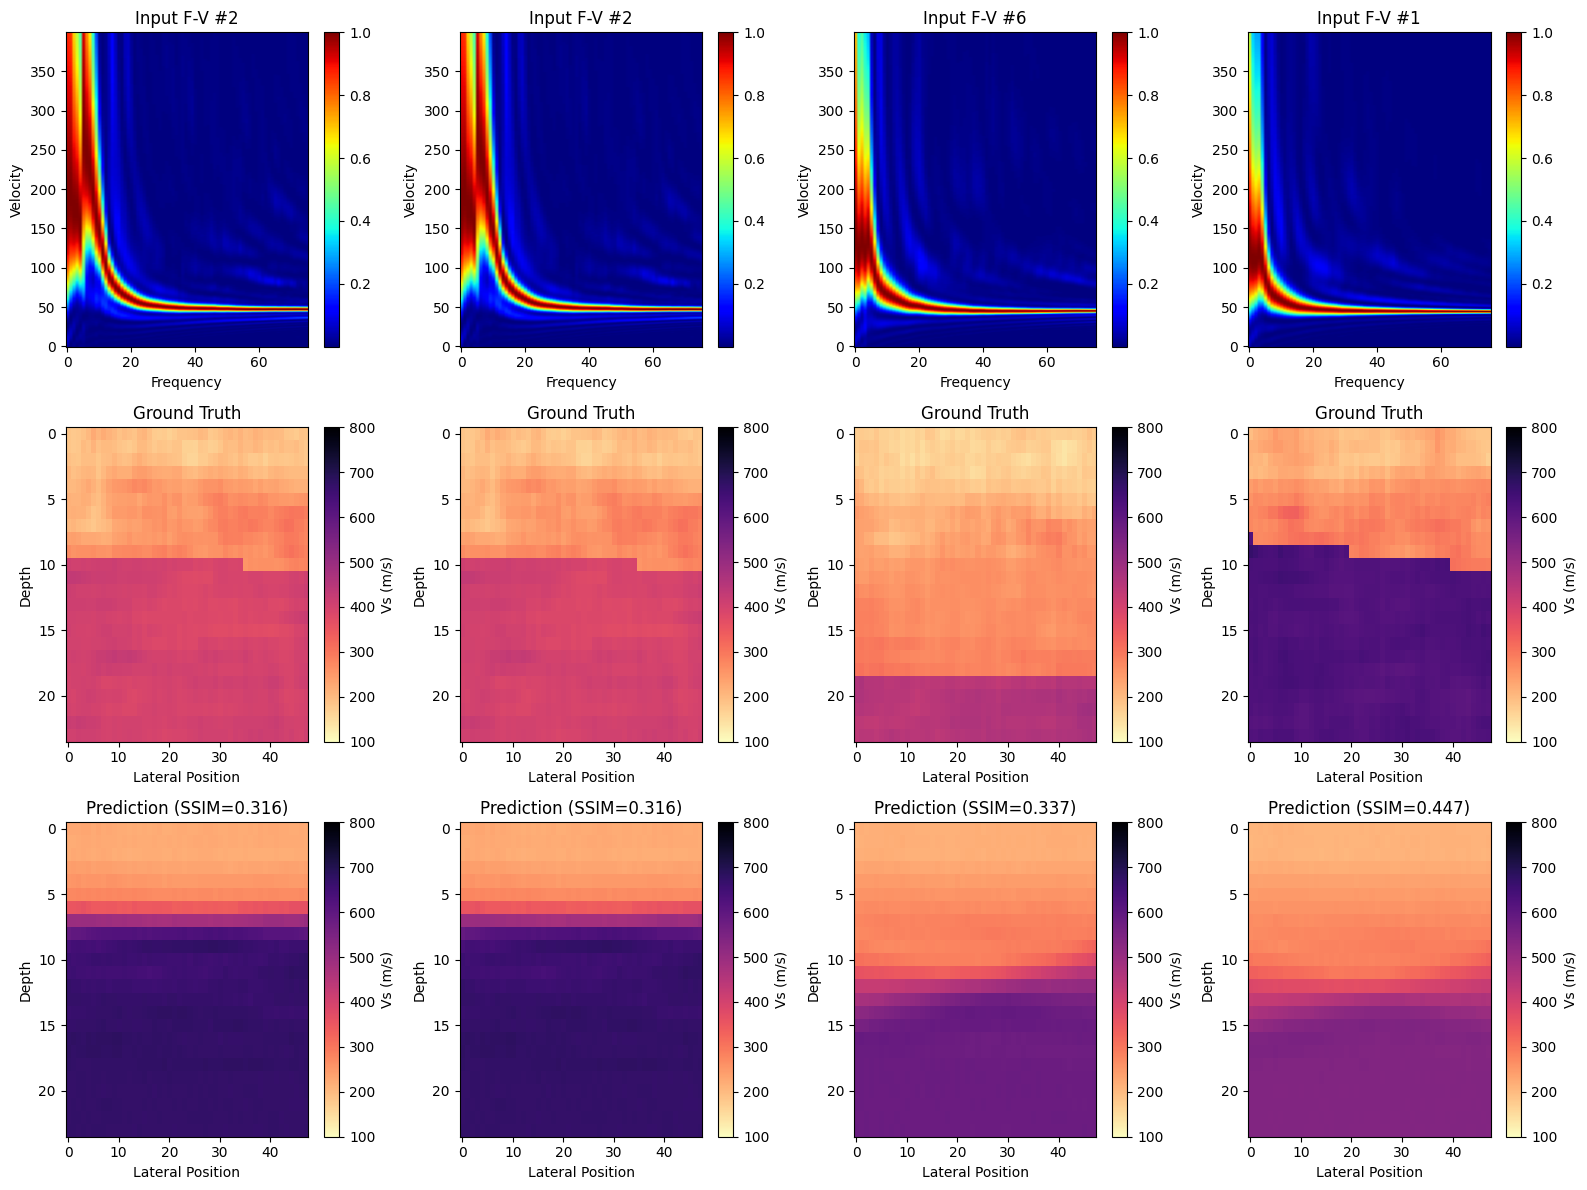


📊 Visualization Statistics:
   Samples visualized: 4
   Selected indices: [2, 2, 6, 1]


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# Plot predictions vs ground truth
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

# Convert tensors to numpy if needed
def to_numpy(x):
    if hasattr(x, 'cpu'):  # PyTorch tensor
        return x.cpu().detach().numpy()
    return np.array(x)

test_inputs_np = to_numpy(test_inputs)
predictions_np = to_numpy(predictions)
targets_np = to_numpy(targets)

# Verify shapes
print(f"test_inputs shape: {test_inputs_np.shape}")
print(f"predictions shape: {predictions_np.shape}")
print(f"targets shape: {targets_np.shape}")

# Pre-select 4 random indices that are valid for all arrays
num_samples = min(len(test_inputs_np), len(predictions_np), len(targets_np))
print(f"Number of valid samples: {num_samples}")

# Generate indices once
selected_indices = [np.random.randint(0, num_samples) for _ in range(4)]

for i in range(4):
    idx = selected_indices[i]

    # Input
    ax = axes[0, i]
    im = ax.imshow(test_inputs_np[idx, 0], aspect='auto', cmap='jet', origin='lower')
    ax.set_title(f'Input F-V #{idx}')
    ax.set_xlabel('Frequency')
    ax.set_ylabel('Velocity')
    plt.colorbar(im, ax=ax)

    # Ground truth
    ax = axes[1, i]
    im = ax.imshow(targets_np[idx], aspect='auto', cmap='magma_r', origin='upper', vmin=100, vmax=800)
    ax.set_title(f'Ground Truth')
    ax.set_xlabel('Lateral Position')
    ax.set_ylabel('Depth')
    plt.colorbar(im, ax=ax, label='Vs (m/s)')

    # Prediction
    ax = axes[2, i]
    im = ax.imshow(predictions_np[idx], aspect='auto', cmap='magma_r', origin='upper', vmin=100, vmax=800)
    ssim_val = ssim(targets_np[idx], predictions_np[idx],
                    data_range=targets_np[idx].max() - targets_np[idx].min())
    ax.set_title(f'Prediction (SSIM={ssim_val:.3f})')
    ax.set_xlabel('Lateral Position')
    ax.set_ylabel('Depth')
    plt.colorbar(im, ax=ax, label='Vs (m/s)')

plt.tight_layout()
plt.show()

# Print statistics
print("\n📊 Visualization Statistics:")
print(f"   Samples visualized: {len(selected_indices)}")
print(f"   Selected indices: {selected_indices}")

## 12. GradCAM Implementation for Interpretation

Based on Jodie Crocker (2023) - Grad-CAM helps visualize which parts of the input are important for the prediction.

In [18]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, x):
        # Forward pass
        output = self.model(x)

        # Backward pass
        self.model.zero_grad()
        output.mean().backward()

        # Calculate Grad-CAM
        gradients = self.gradients
        activations = self.activations

        # Global average pooling of gradients
        weights = gradients.mean(dim=(2, 3), keepdim=True)

        # Weighted combination of activation maps
        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)  # ReLU to focus on positive influence

        # Normalize to [0, 1]
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam


# Create GradCAM instance (using last conv layer)
gradcam = GradCAM(model, model.conv4[0])  # Conv4 layer

print("✅ GradCAM ready for visualization")

✅ GradCAM ready for visualization


## 13. Visualize GradCAM Heatmaps

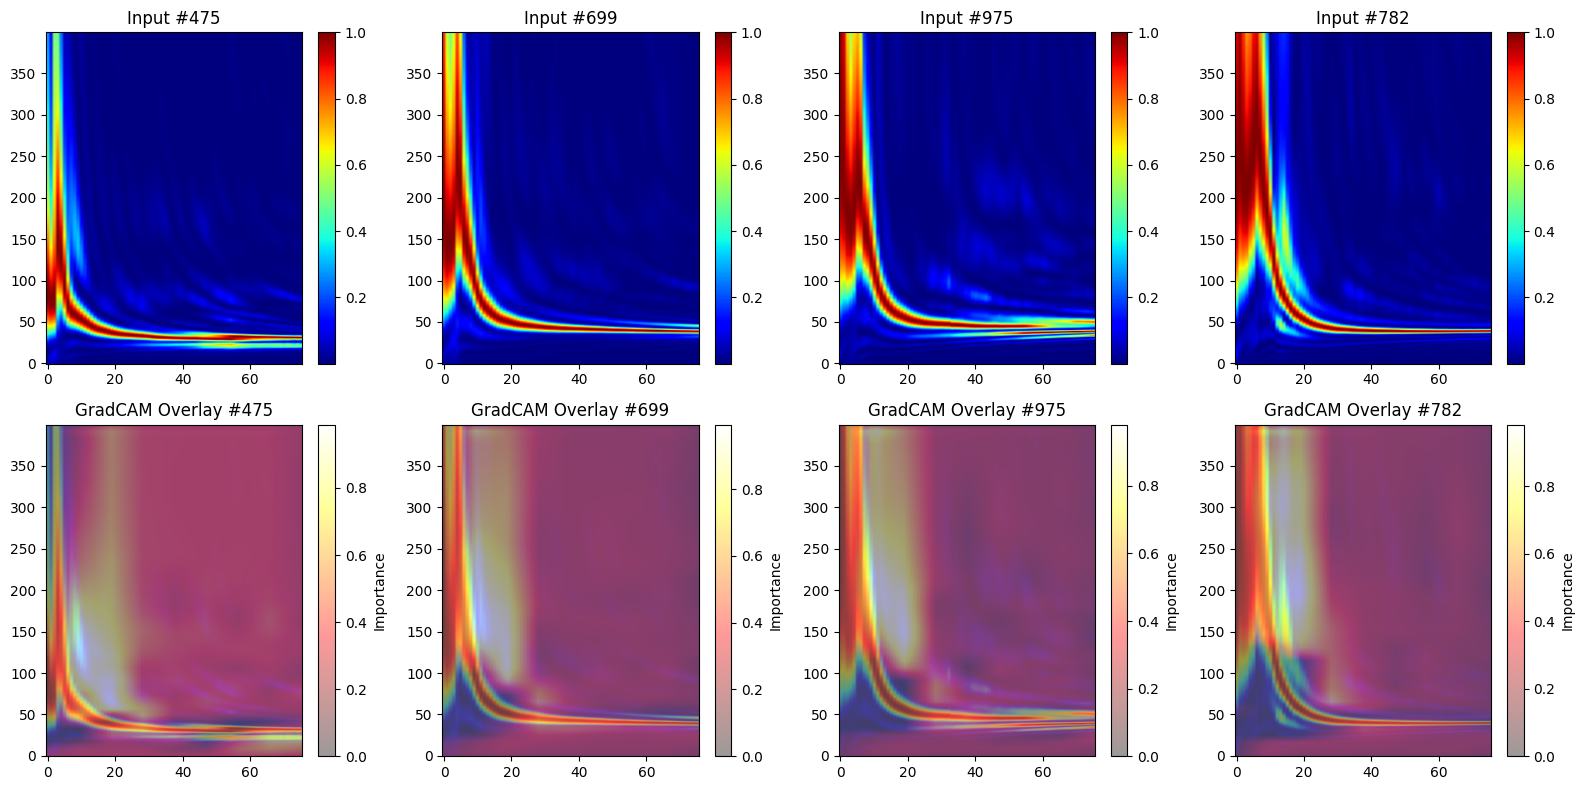

📊 GradCAM shows which frequency-velocity features are most important for predictions


In [19]:
# Generate GradCAM for sample inputs
model.eval()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    idx = np.random.randint(0, len(test_inputs))

    # Get input
    input_tensor = torch.FloatTensor(test_inputs[idx:idx+1]).to(device)
    input_tensor.requires_grad = True

    # Generate GradCAM
    cam = gradcam(input_tensor)
    cam_np = cam.squeeze().cpu().numpy()

    # Resize CAM to match input size
    from scipy.ndimage import zoom
    cam_resized = zoom(cam_np,
                      (test_inputs[idx, 0].shape[0] / cam_np.shape[0],
                       test_inputs[idx, 0].shape[1] / cam_np.shape[1]),
                      order=1)

    # Plot input
    ax = axes[0, i]
    im = ax.imshow(test_inputs[idx, 0], aspect='auto', cmap='jet', origin='lower')
    ax.set_title(f'Input #{idx}')
    plt.colorbar(im, ax=ax)

    # Plot GradCAM overlay
    ax = axes[1, i]
    ax.imshow(test_inputs[idx, 0], aspect='auto', cmap='jet', origin='lower', alpha=0.6)
    im = ax.imshow(cam_resized, aspect='auto', cmap='hot', origin='lower', alpha=0.4)
    ax.set_title(f'GradCAM Overlay #{idx}')
    plt.colorbar(im, ax=ax, label='Importance')

plt.tight_layout()
plt.show()

print("📊 GradCAM shows which frequency-velocity features are most important for predictions")

## 14. Save and Load Model

In [20]:
# Model is already saved during training
print(f"✅ Model saved to: best_fwi_cnn.pth")

# To load the model later:
# model_loaded = FrequencyVelocityCNN()
# model_loaded.load_state_dict(torch.load('best_fwi_cnn.pth'))
# model_loaded = model_loaded.to(device)
# model_loaded.eval()

✅ Model saved to: best_fwi_cnn.pth


## 15. Summary

### What We Accomplished

1. **Implemented Frequency-Velocity CNN**
   - PyTorch implementation with MPS/CUDA support
   - 4 convolutional blocks + 3 dense layers
   - ~26M parameters for complex inversion

2. **Training on Geophysical Data**
   - 2,000 training samples (4 files)
   - 1,000 testing samples (2 files)
   - Input: Frequency-velocity transforms (400×76)
   - Output: 2D Vs velocity models (24×48)

3. **Model Interpretation with GradCAM**
   - Visualized important features in dispersion curves
   - Identified frequency-velocity patterns critical for inversion

4. **Performance Metrics**
   - MSE, MAE, R², and SSIM
   - Comparison of predicted vs true velocity models

### Applications in Geotechnical Engineering

- **Near-surface velocity characterization**
- **Site investigation and geohazard assessment**
- **Real-time seismic monitoring**
- **Foundation design optimization**

### Next Steps

- Train on full dataset (all 10 files)
- Experiment with different architectures
- Add uncertainty quantification
- Deploy for real-time predictions